# **Classification: XGBoost Classifier**

## **Justification of Preprocessing Strategy**

### **Scale Invariance**
**XGBoost** is an ensemble algorithm built entirely upon decision trees. Like a single Decision Tree or a Random Forest, it partitions data through discrete feature thresholds rather than geometric distances. This operational logic makes the model mathematically **invariant to the scale** of the input data. Applying standardization or normalization would result in the exact same splits and predictions while incurring an unnecessary computational cost. Therefore, to maximize processing efficiency, we will train the model using the **Original, Unscaled Data**.

### **Computational Power and The Overfitting Trap**
XGBoost is exceptionally powerful, utilizing parallel processing to build sequential trees rapidly, making it ideal for our dataset of 100,000 samples. However, its aggressive learning strategy means it is highly prone to memorizing the training data. While XGBoost natively includes L1/L2 regularization to combat this, we must actively monitor its learning curve. By logging **both Train and Test metrics** simultaneously in MLflow across all runs, we can easily spot if the model achieves near-perfect Train Recall while failing on the Test set, allowing us to reject overfitted configurations.


## **Experiment Design**

We have designed a rigorous tournament of **3 optimization levels** focused on structural and learning parameters. In strict adherence to our clinical evaluation strategy, all optimization algorithms are explicitly instructed to maximize **Recall** as the primary scoring metric:

* **Baseline (Strict Defaults)**: Executing the XGBoost Classifier with the library's factory default parameters (`eval_metric="logloss"`) to establish our absolute performance benchmark.
* **GridSearchCV**: An exhaustive, 3-fold cross-validated search using discrete structural intervals: **`n_estimators`** [50, 100], **`learning_rate`** [0.05, 0.1], and **`max_depth`** [3, 5]. 
* **Optuna Optimization**: Bayesian optimization utilizing the exact same boundaries

In [ ]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, accuracy_score, f1_score

# MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Classification_XGBoost")

# Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_final.drop(["diagnosed_diabetes", "diabetes_stage"], axis=1)
y = df_final['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def log_classification_metrics(model, X_tr, y_tr, X_te, y_te, duration):
    # Logs both Train and Test metrics to evaluate Overfitting/Underfitting
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    
    # Train Partition Metrics
    mlflow.log_metric("recall_train", recall_score(y_tr, y_tr_pred))
    mlflow.log_metric("accuracy_train", accuracy_score(y_tr, y_tr_pred))
    mlflow.log_metric("f1_train", f1_score(y_tr, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("recall_test", recall_score(y_te, y_te_pred))
    mlflow.log_metric("accuracy_test", accuracy_score(y_te, y_te_pred))
    mlflow.log_metric("f1_test", f1_score(y_te, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE 
# ---------------------------------------------------------
with mlflow.start_run(run_name="XGB_Baseline_Defaults"):
    xgb_base = XGBClassifier(random_state=42, eval_metric="logloss")
    
    start_time = time.time()
    xgb_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    mlflow.log_params(xgb_base.get_params())
    mlflow.log_param("optimization", "none_default")
    
    log_classification_metrics(xgb_base, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV 
# ---------------------------------------------------------
with mlflow.start_run(run_name="XGB_GridSearch"):
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
    
    grid = GridSearchCV(
        XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1),
        param_grid, cv=3, scoring='recall', n_jobs=-1
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    duration = time.time() - start_time
    
    best_xgb_grid = grid.best_estimator_
    
    mlflow.log_params(grid.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    
    log_classification_metrics(best_xgb_grid, X_train, y_train, X_test, y_test, duration)

# ---------------------------------------------------------
# RUN 3: OPTUNA 
# ---------------------------------------------------------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.1),
        "max_depth": trial.suggest_int("max_depth", 3, 5)
    }
    
    model = XGBClassifier(**params, random_state=42, eval_metric="logloss")
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='recall', n_jobs=-1).mean()
    return score

with mlflow.start_run(run_name="XGB_Optuna"):
    study = optuna.create_study(direction="maximize")
    start_time = time.time()
    study.optimize(objective, n_trials=10) 
    duration = time.time() - start_time
    
    best_xgb_opt = XGBClassifier(**study.best_params, random_state=42, eval_metric="logloss")
    best_xgb_opt.fit(X_train, y_train)
    
    mlflow.log_params(study.best_params)
    mlflow.log_param("optimization", "optuna")
    
    log_classification_metrics(best_xgb_opt, X_train, y_train, X_test, y_test, duration)

[I 2026-05-23 14:09:41,632] A new study created in memory with name: no-name-83208107-84c1-4600-b544-1c800a39000f
[I 2026-05-23 14:09:42,673] Trial 0 finished with value: 0.8689736793445423 and parameters: {'n_estimators': 79, 'learning_rate': 0.08097863758509141, 'max_depth': 3}. Best is trial 0 with value: 0.8689736793445423.
[I 2026-05-23 14:09:43,773] Trial 1 finished with value: 0.8689736793445423 and parameters: {'n_estimators': 91, 'learning_rate': 0.06472756842292202, 'max_depth': 5}. Best is trial 0 with value: 0.8689736793445423.
[I 2026-05-23 14:09:44,884] Trial 2 finished with value: 0.8689736793445423 and parameters: {'n_estimators': 94, 'learning_rate': 0.08776487411799, 'max_depth': 3}. Best is trial 0 with value: 0.8689736793445423.
[I 2026-05-23 14:09:45,816] Trial 3 finished with value: 0.8689736793445423 and parameters: {'n_estimators': 61, 'learning_rate': 0.06734163473800411, 'max_depth': 5}. Best is trial 0 with value: 0.8689736793445423.
[I 2026-05-23 14:09:46,76

## Winner Run Selection

### Policy
- Mandatory generalization filter: |Recall_test − Recall_train| ≤ 0.005 AND |F1_test − F1_train| ≤ 0.005. Any run failing this is disqualified.

### Selection Criteria (priority order)
1. **Priority 1 (70% weight): Highest Recall (Test)** — clinical priority: maximize detection of positive diabetes cases.
2. **Priority 2 (30% weight): Highest F1-Score (Test)** — tie-breaker when Recall ties or differs by <0.5%.
3. **Accuracy is visible but ignored** — shown for reference only; not used in selection.
4. **Tiebreaker: Lowest Fit Time** — if Recall and F1 remain tied.

### All Runs: Summary Table (Train/Test metrics shown)

| Run | Accuracy (Train) | Accuracy (Test) | Recall (Train) | Recall (Test) | F1 (Train) | F1 (Test) | Fit Time (s) | Gen. Filter | Recall Gap | F1 Gap |
|---|---:|---:|---:|---:|---:|---:|---:|:--:|---:|---:|
| XGB_Baseline_Defaults | 0.93246 | 0.91755 | 0.86897 | 0.86742 | 0.92989 | 0.92660 | 0.45 | PASS | -0.00155 | -0.00329 |
| XGB_GridSearch | 0.92139 | 0.91990 | 0.86897 | 0.86650 | 0.92989 | 0.92848 | 3.98 | PASS | -0.00247 | -0.00141 |
| XGB_Optuna | 0.92139 | 0.91990 | 0.86897 | 0.86650 | 0.92989 | 0.92848 | 10.24 | PASS | -0.00247 | -0.00141 |

### Step-by-step Elimination

**Step 1: Apply Generalization Filter (absolute gaps ≤ 0.005)**
- All runs pass the generalization check; none disqualified.

**Step 2: Filter by Highest Test Recall (Priority 1 — 70%)**
- Best Recall (Test): 0.86742 (XGB_Baseline_Defaults).
- Candidates passing: XGB_Baseline_Defaults.
- Eliminated: XGB_GridSearch, XGB_Optuna (both 0.86650).

**Step 3: Verify F1 (Priority 2 — 30%)**
- Not required: only baseline remains after step 2.

**Step 4: Tiebreaker (Fit Time)**
- Not required.

### Final Decision
**Winner: XGB_Baseline_Defaults**

**Justification:** Baseline achieves highest Test Recall (0.86742) and is fastest (0.45 s). GridSearch and Optuna provide marginal Accuracy/F1 changes without Recall gain and are slower; therefore baseline selected per clinical priority.

### Winner Hyperparameters (Baseline)

| Parameter | Value |
|---|---|
| booster | gbtree |
| objective | binary:logistic |
| eval_metric | logloss |
| random_state | 42 |
| n_estimators | 100 (default) |
| learning_rate | 0.3 (default) |
| max_depth | 6 (default) |

### Overfitting/Underfitting Diagnosis
- Train vs Test gaps are small; both Recall and F1 gaps are within ±0.5 percentage points, indicating good generalization.
- No evidence of severe overfitting: train Recall ≈ test Recall.
- Recommendation: keep baseline for production; further hyperparameter search can focus on recall improvements (e.g., scale_pos_weight, min_child_weight, lower learning_rate with more estimators) if desired.


---

# **Dimensionality Reduction: PCA via Singular Value Decomposition (SVD)**

## **Justification of Preprocessing & Algorithm Choice**

### **The Scaling Paradox for Tree-Based Ensembles**
As established earlier, XGBoost is a tree-based ensemble that is inherently scale-invariant, meaning it prefers the raw, unscaled feature thresholds. However, **Principal Component Analysis (PCA) via SVD is highly scale-sensitive**, as it calculates geometric variance across orthogonal axes. Therefore, we encounter a necessary preprocessing paradox: we must explicitly standardize the data (`StandardScaler`) *before* applying the SVD transformation, even though our base model does not natively require it.

### **The Tree Abstraction Trade-off**
Decision trees thrive on making discrete logical splits on clear clinical variables (e.g., `glucose > 120`). SVD compresses these readable variables into dense, abstract "principal components". By capturing 95% of the variance, we will test whether XGBoost benefits from a smaller, denser matrix (faster computation) or if the loss of original feature thresholds degrades its powerful splitting mechanics.

Original Features: 54
SVD Components needed for 95% variance: 27

--- PCA/SVD IMPACT ON XGBOOST ---
Original Space -> Fit Time: 0.4394s | Recall: 0.8674
SVD Space      -> Fit Time: 0.4493s | Recall: 0.8552

Execution Time Change: +2.2%


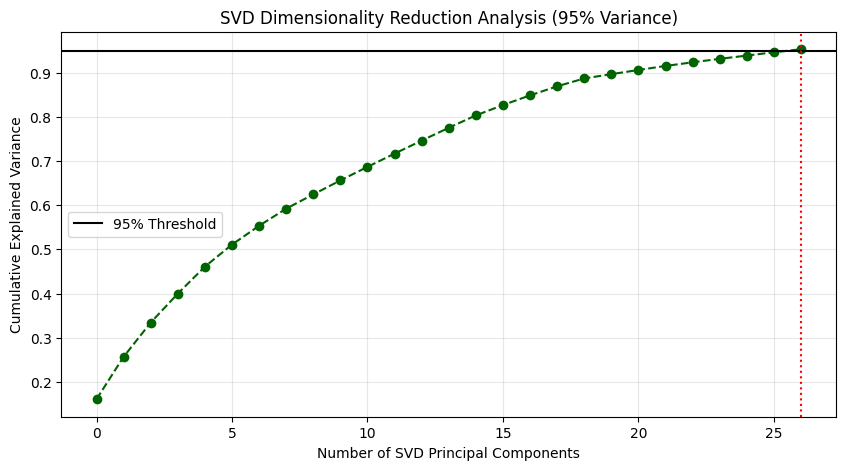

In [ ]:
# ---------------------------------------------------------
# PCA / SVD 
# ---------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mlflow.set_experiment("Classification_XGBoost_PCA_SVD")

# Identify numerical columns and apply StandardScaler (Mandatory for PCA/SVD)
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns 

scaler_pca = StandardScaler()
X_train_scaled_for_pca = X_train.copy()
X_test_scaled_for_pca = X_test.copy()
X_train_scaled_for_pca[num_cols] = scaler_pca.fit_transform(X_train[num_cols])
X_test_scaled_for_pca[num_cols] = scaler_pca.transform(X_test[num_cols])

# Execute PCA via SVD (95% Variance)
pca_svd = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_svd = pca_svd.fit_transform(X_train_scaled_for_pca)
X_test_svd = pca_svd.transform(X_test_scaled_for_pca)

n_components_chosen = pca_svd.n_components_
print(f"Original Features: {X_train.shape[1]}")
print(f"SVD Components needed for 95% variance: {n_components_chosen}\n")

# Define the Champion Model (XGB_Baseline_Defaults winner params)
# RUN A: Champion in Original Space (Unscaled, as XGBoost natively prefers)
with mlflow.start_run(run_name="XGB_Champion_Original_Space"):
    model_orig = XGBClassifier(random_state=42, eval_metric="logloss")
    
    start_time = time.time()
    model_orig.fit(X_train, y_train)
    time_orig = time.time() - start_time
    
    y_pred_orig = model_orig.predict(X_test)
    recall_orig = recall_score(y_test, y_pred_orig)
    
    mlflow.log_param("space", "Original_Unscaled")
    mlflow.log_metric("fit_time", time_orig)
    mlflow.log_metric("recall_test", recall_orig)

# RUN B: Champion in SVD Reduced Space
with mlflow.start_run(run_name="XGB_Champion_SVD_Space"):
    model_svd = XGBClassifier(random_state=42, eval_metric="logloss")
    
    start_time = time.time()
    model_svd.fit(X_train_svd, y_train)
    time_svd = time.time() - start_time
    
    y_pred_svd = model_svd.predict(X_test_svd)
    recall_svd = recall_score(y_test, y_pred_svd)
    
    mlflow.log_param("space", f"SVD_{n_components_chosen}_comps")
    mlflow.log_metric("fit_time", time_svd)
    mlflow.log_metric("recall_test", recall_svd)

# Print Results
print("--- PCA/SVD IMPACT ON XGBOOST ---")
print(f"Original Space -> Fit Time: {time_orig:.4f}s | Recall: {recall_orig:.4f}")
print(f"SVD Space      -> Fit Time: {time_svd:.4f}s | Recall: {recall_svd:.4f}")

time_diff = ((time_svd - time_orig) / time_orig) * 100
print(f"\nExecution Time Change: {time_diff:+.1f}%")

# Scree Plot for the Report
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_svd.explained_variance_ratio_), marker='o', linestyle='--', color='darkgreen')
plt.xlabel('Number of SVD Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Dimensionality Reduction Analysis (95% Variance)')
plt.axhline(y=0.95, color='black', linestyle='-', label='95% Threshold')
plt.axvline(x=n_components_chosen-1, color='red', linestyle=':')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**PCA/SVD Impact on XGBoost**

Reducing the feature space from 54 variables to 27 SVD components did not help this model. The fit time slightly increased from 0.4394 s to 0.4493 s, a +2.2% change, so there is no computational gain. At the same time, Recall dropped from 0.8674 to 0.8552, meaning the reduced space lost useful predictive information.

For XGBoost, this result is expected: tree-based models usually benefit more from the original feature thresholds than from dense principal components. Even though the SVD retained 95% of the variance, that did not preserve the most relevant signal for classification.

Conclusion: for this algorithm, the original feature space is the better choice. PCA/SVD is not recommended here.